# Cafe Sales Analysis: Feature Engineering & EDA Strategy
**Objective:** Discover patterns in customer behavior and sales trends to identify high-value signals for predictive modeling (e.g., demand forecasting).

---

### 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

### 2. Data Loading & Feature Extraction
We transform raw transaction dates into categorical time features to capture seasonal/weekly variations.

In [2]:
df = pd.read_csv("cleaned_cafe_sales_data.csv")

# Convert to datetime and extract time features
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["transaction_day"] = df["transaction_date"].dt.day_name()
df["transaction_month"] = df["transaction_date"].dt.month_name()

df.head()

,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,transaction_day,transaction_month
0,Tea,3,1.5,4.5,Digital Wallet,In-store,2023-01-01,Sunday,January
1,Coffee,4,2.0,8.0,Digital Wallet,In-store,2023-01-01,Sunday,January
2,Sandwich,5,4.0,20.0,Cash,In-store,2023-01-01,Sunday,January
3,Coffee,2,2.0,4.0,Cash,In-store,2023-01-01,Sunday,January
4,Coffee,2,2.0,4.0,Digital Wallet,Takeaway,2023-01-01,Sunday,January


## 3. Sales Performance Analysis

#### 3.1 Total Revenue by Product
Identifying the "Cash Cows" vs. low-revenue items.

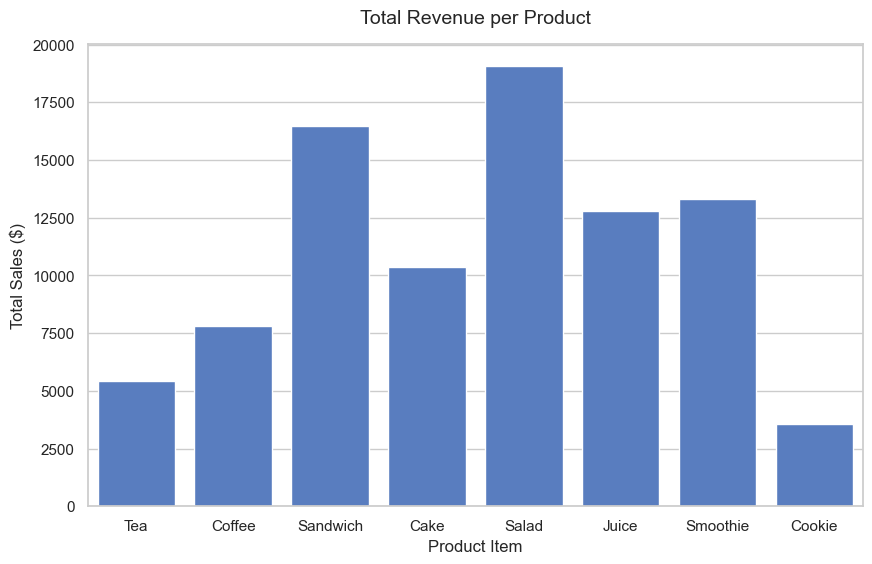

In [3]:
sns.barplot(data=df, x='item', y='total_spent', estimator=np.sum, errorbar=None)
plt.title("Total Revenue per Product", fontsize=14, pad=15)
plt.xlabel("Product Item")
plt.ylabel("Total Sales ($)")
plt.show()

#### 3.2 Daily Sales Trends
Checking for data stability and identifying potential anomalies or seasonal spikes.

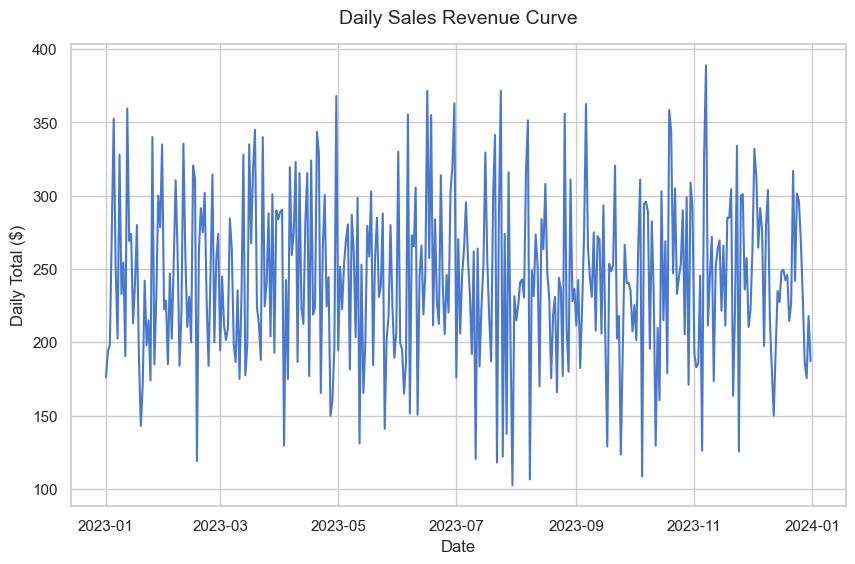

In [4]:
sns.lineplot(data=df, x='transaction_date', y='total_spent', estimator=np.sum, errorbar=None)
plt.title("Daily Sales Revenue Curve", fontsize=14, pad=15)
plt.xlabel("Date")
plt.ylabel("Daily Total ($)")
plt.show()

#### 3.3 Monthly Performance
Visualizing macro trends over the year.

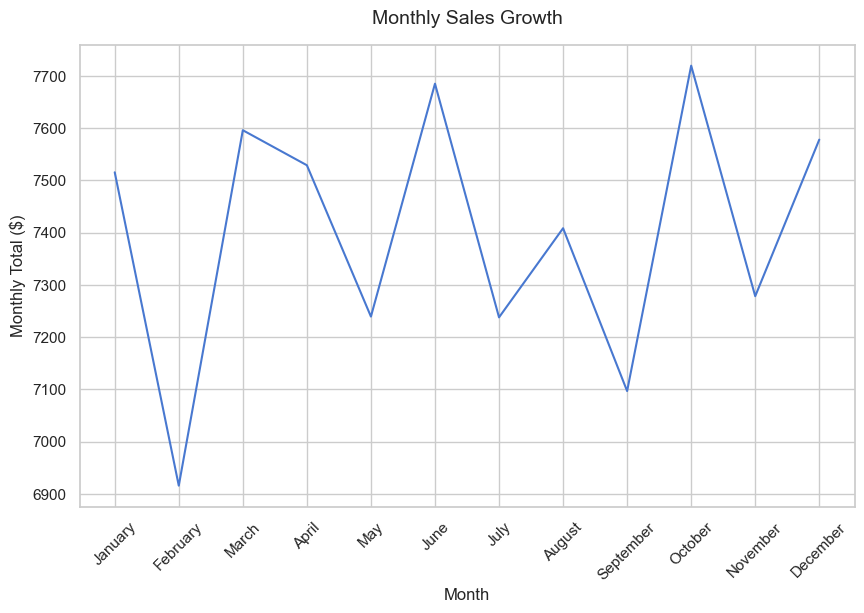

In [5]:
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]

sns.lineplot(data=df, x='transaction_month', y='total_spent', 
             estimator=np.sum, errorbar=None, sort=False)
plt.xticks(rotation=45)
plt.title("Monthly Sales Growth", fontsize=14, pad=15)
plt.xlabel("Month")
plt.ylabel("Monthly Total ($)")
plt.show()

## 4. Customer Behavior & Segments

#### 4.1 Payment Method vs. Transaction Value
Does payment method correlate with high-ticket orders? (Useful for promotional targeting).

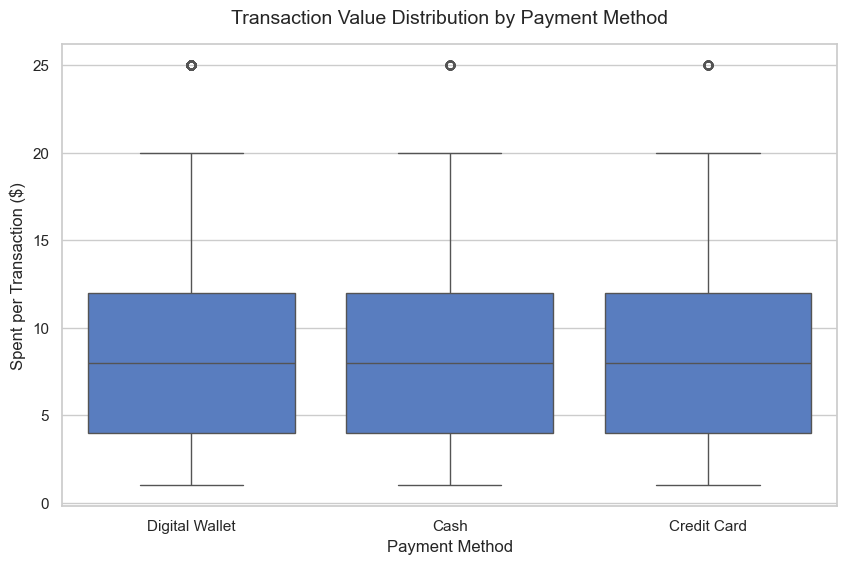

In [6]:
sns.boxplot(data=df, x='payment_method', y='total_spent')
plt.title("Transaction Value Distribution by Payment Method", fontsize=14, pad=15)
plt.xlabel("Payment Method")
plt.ylabel("Spent per Transaction ($)")
plt.show()

#### 4.2 Location & Payment Preference
Understanding operational dynamics: In-store vs. Takeaway.

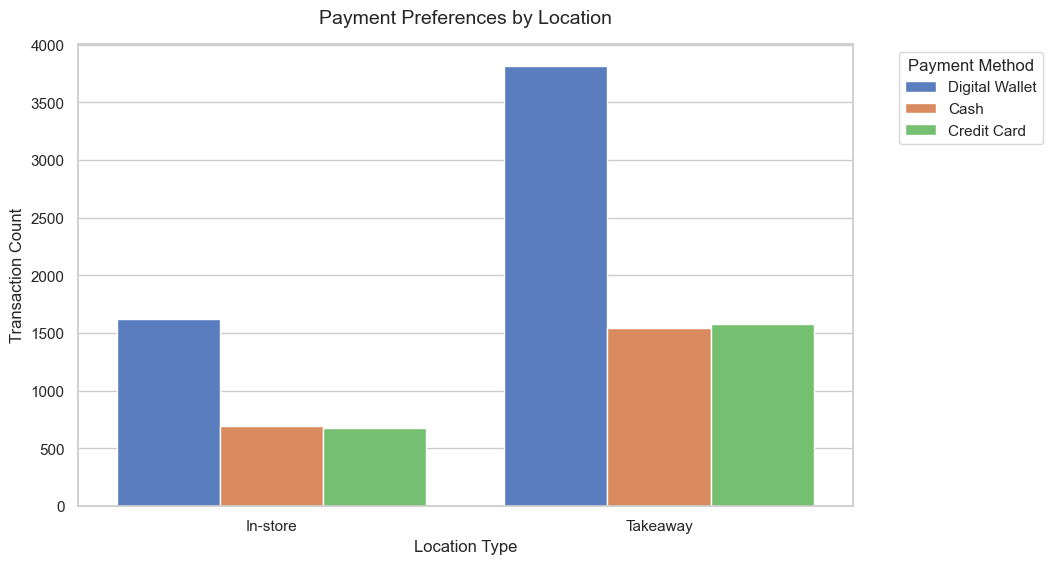

In [7]:
sns.countplot(data=df, x='location', hue='payment_method')
plt.title("Payment Preferences by Location", fontsize=14, pad=15)
plt.xlabel("Location Type")
plt.ylabel("Transaction Count")
plt.legend(title="Payment Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 5. Product Dynamics & Timing

#### 5.1 Weekly Revenue Distribution
Identifying peak days to optimize staffing or inventory.

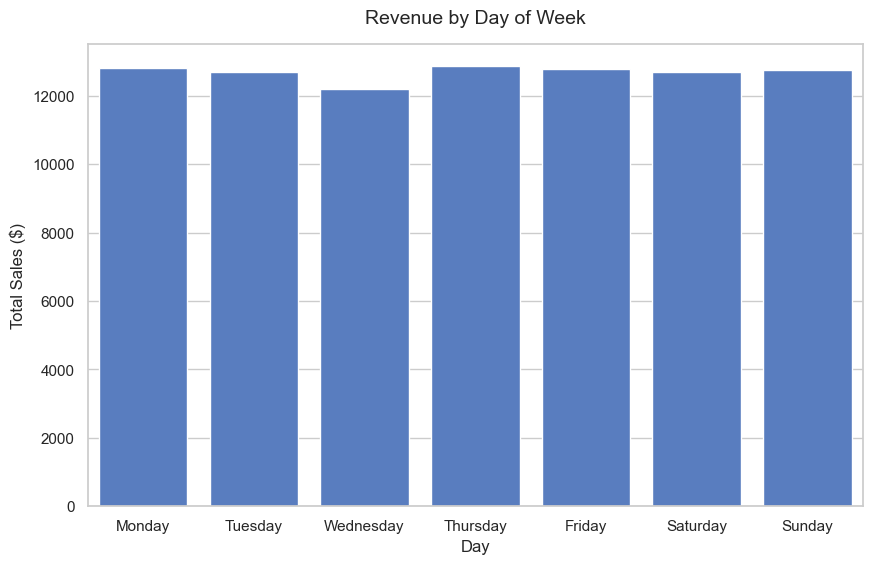

In [8]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='transaction_day', y='total_spent', order=day_order, estimator=np.sum, errorbar=None)
plt.title("Revenue by Day of Week", fontsize=14, pad=15)
plt.xlabel("Day")
plt.ylabel("Total Sales ($)")
plt.show()

#### 5.2 Product Popularity by Day
Does "Coffee" peak on Mondays while "Sandwiches" peak on weekends?

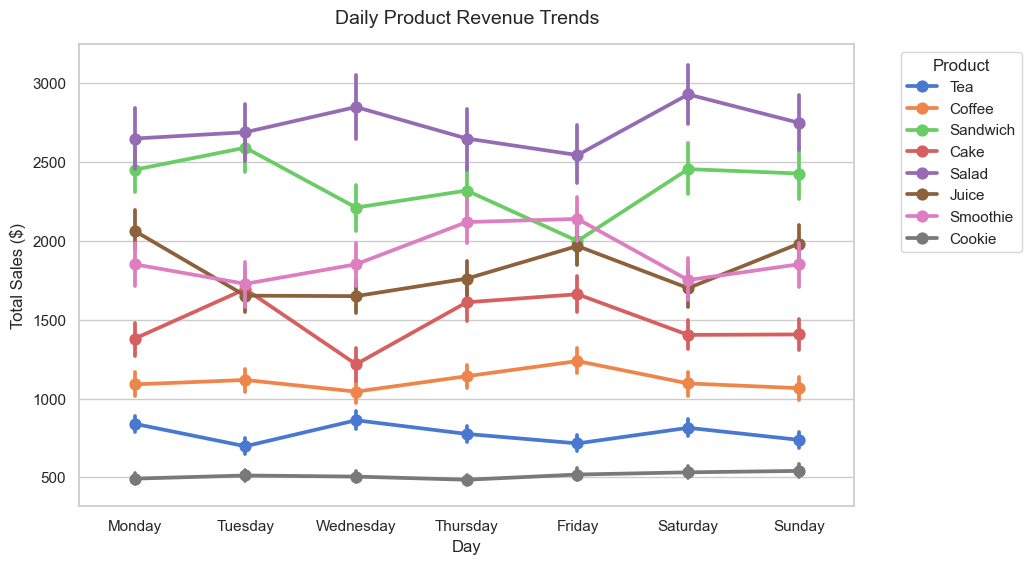

In [9]:
sns.pointplot(data=df, x='transaction_day', y='total_spent', hue='item', order=day_order, estimator=np.sum)
plt.title("Daily Product Revenue Trends", fontsize=14, pad=15)
plt.xlabel("Day")
plt.ylabel("Total Sales ($)")
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## EDA Summary & Insights
1. **Trend Analysis:** Sales show a stable upward trajectory over time, with clear weekly seasonality.
2. **Product Performance:** Certain items dominate revenue, suggesting they are the primary drivers of store traffic.
3. **Customer Segments:** Payment methods are evenly distributed, but takeaway vs. in-store volume varies, which could be a useful feature for predicting transaction speed.
4. **AI Signal Potential:** The `transaction_day` and `item` are high-signal features for any future demand forecasting model.